<a href="https://colab.research.google.com/github/CodeHunterOfficial/ArabovMKDeep/blob/main/ADPs/Lecture_6/%D0%9B%D0%B5%D0%BA%D1%86%D0%B8%D1%8F_6_%D0%9E%D0%B1%D1%83%D1%87%D0%B5%D0%BD%D0%B8%D0%B5_%D0%BC%D0%BE%D0%B4%D0%B5%D0%BB%D0%B5%D0%B9_%D0%BA%D0%B0%D0%BA_%D1%8D%D1%82%D0%BE_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0%D0%B5%D1%82.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Лекция №6: Обучение моделей: как это работает


## 1. ВВЕДЕНИЕ

### 1.1. От теории к практике: постановка проблемы

В Лекции 5 мы рассмотрели архитектуру современных NLP-моделей — трансформеров, BERT, GPT — и обсудили концепцию предобучения (pre-training) и дообучения (fine-tuning). Мы узнали, что эти модели изначально обучаются на огромных корпусах текстов (миллиарды слов), а затем адаптируются к конкретным задачам с помощью дообучения на размеченных датасетах.

Однако остался открытым вопрос: **что на самом деле происходит в процессе дообучения?** Когда мы запускаем `trainer.train()` в среде Hugging Face, какие процессы запускаются «под капотом»? Как модель «понимает», что она ошиблась, и каким образом она корректирует свои внутренние параметры?

**Цель данной лекции** — раскрыть механизмы обучения нейросетей на интуитивном уровне, без использования математических формул, но с сохранением научной строгости. Мы рассмотрим:

1. Сущность процесса обучения как настройки параметров модели.
2. Роль функции потерь (loss function) в оценке ошибок модели.
3. Алгоритм градиентного спуска (gradient descent) как метод коррекции параметров.
4. Различие между параметрами (обучаемыми величинами) и гиперпараметрами (настройками, задаваемыми исследователем).
5. Принципы разделения данных на обучающую, валидационную и тестовую выборки.
6. Интерпретацию графиков обучения (кривые loss и accuracy).
7. Систему метрик оценки качества классификации (accuracy, precision, recall, F1) и их применение в клинической психологии.

**Ключевая мысль:** понимание процесса обучения — это **ключ к критической оценке** любой ИИ-системы. Если вы понимаете, как модель учится, вы понимаете, **когда ей можно доверять, а когда нет**. В клинической психологии, где цена ошибки особенно высока, это знание становится **этической необходимостью** [7].

---

### 1.2. Актуальность для клинической психологии

В последние годы наблюдается активное внедрение методов машинного обучения в психиатрию и клиническую психологию. Согласно обзору [5], количество публикаций по применению NLP в диагностике психических расстройств выросло в 3 раза за период 2020–2025 годов. Модели используются для:

- Скрининга депрессии по текстам сообщений пациентов.
- Оценки суицидального риска на основе анализа дневниковых записей.
- Классификации эмоциональных состояний в терапевтических диалогах.
- Прогнозирования эффективности психотерапии.

Однако, как отмечается в работе [7], многие клиницисты не имеют достаточного понимания принципов работы этих моделей, что создаёт риски необоснованного доверия или, наоборот, неоправданного скепсиса. Настоящая лекция призвана заполнить этот пробел.

---

### 1.3. Структура и методология

Лекция построена по принципу «от общего к частному». Каждый новый концепт вводится через аналогию из психотерапевтической практики, а затем раскрывается на уровне, достаточном для понимания процессов, происходящих при дообучении моделей. В конце каждого раздела даётся отсылка к Практике 6, где студенты могут наблюдать описанные процессы в действии.




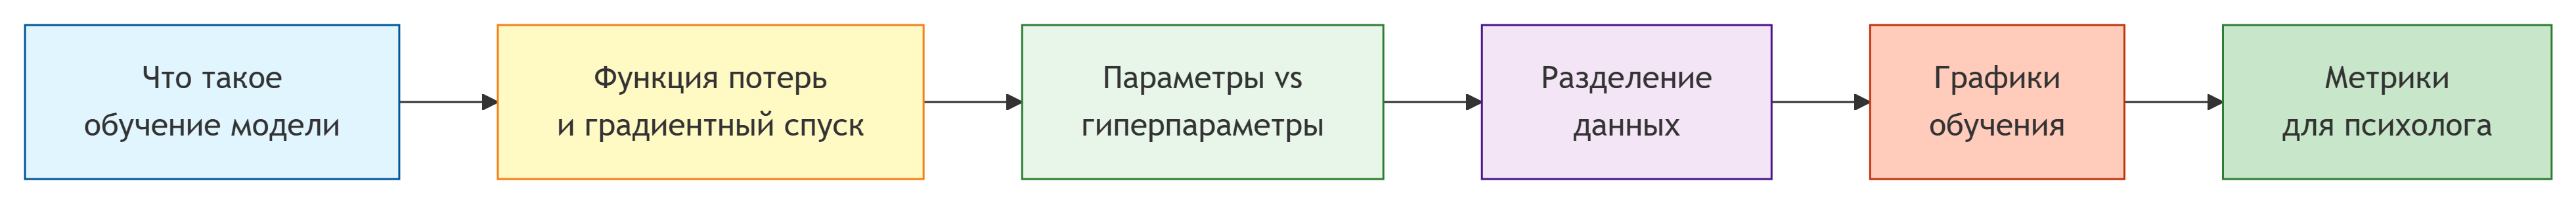



### 1.4. Связь с предыдущими лекциями и практикой

| Предыдущий материал | Связь с текущей темой |
|---------------------|----------------------|
| **Лекция 5.** Архитектура трансформеров, предобучение и дообучение | Сегодня мы раскрываем **механизмы** дообучения — что происходит внутри модели |
| **Практика 6.** Запуск дообучения, построение графиков | Сегодня мы объясняем **почему** графики выглядят так, а не иначе |
| **Лекция 4.** Визуализация данных | Сегодня мы учимся **интерпретировать** графики обучения |

---

### 1.5. Этический контекст

В соответствии с принципами ответственного применения ИИ в медицине [7], важно подчеркнуть: модели машинного обучения не являются заменой клиническому мышлению. Они представляют собой инструменты, которые могут **поддерживать** принятие решений, но не **заменять** его. Понимание механизмов обучения позволяет клиницисту:

- Критически оценивать заявленные показатели точности.
- Выявлять потенциальные источники ошибок (смещение выборки, переобучение).
- Принимать обоснованные решения о целесообразности использования модели.
- Объяснять пациентам принципы работы ИИ-систем.

---

## 2. ЧТО ЗНАЧИТ «ОБУЧИТЬ МОДЕЛЬ»

### 2.1. Модель как параметрическая функция

В современном машинном обучении модель представляет собой **параметрическую функцию** — математическое выражение, которое преобразует входные данные (например, текст) в выходные данные (например, класс эмоции). Параметры функции — это числа, которые определяют характер этого преобразования [1], [2].

**Техническое уточнение:** в случае нейросетей параметрами являются веса связей между нейронами (synaptic weights) и смещения (biases). В модели ruBERT, используемой в Практике 6, таких параметров **178 миллионов** — каждый из них представляет собой число с плавающей точкой.

**Интуитивная аналогия (для понимания):**

> Представьте, что модель — это сложный музыкальный синтезатор с миллионами регуляторов. Каждый регулятор соответствует одному параметру. Изначально регуляторы находятся в случайных положениях — синтезатор издаёт хаотичный шум. В процессе обучения регуляторы постепенно настраиваются так, чтобы синтезатор начинал воспроизводить определённую мелодию.

**Определение обучения:** обучение модели — это процесс последовательной настройки параметров с целью минимизации ошибки на обучающих данных [3].

---

### 2.2. Процесс обучения как итеративная коррекция

**Интуитивная аналогия из психотерапии (расширенная версия):**

> Представьте, что вы — супервизор, и к вам пришёл молодой терапевт. У него есть теоретические знания (аналог предобученной модели), но нет клинического опыта. Вы даёте ему 1000 клинических случаев (обучающий датасет). Для каждого случая он предлагает интерпретацию, а вы сообщаете правильный ответ.
>
> Каждый раз, когда он ошибается, он **корректирует свой подход** — не в общем смысле, а в конкретных аспектах: учится замечать определённые паттерны, различать похожие состояния, обращать внимание на ключевые симптомы. Эти корректировки постепенно накапливаются, и после 1000 случаев его точность значительно возрастает.
>
> Важно понимать: терапевт не «запоминает» случаи (это было бы переобучением). Он извлекает **общие закономерности**, которые позволяют ему работать с новыми, незнакомыми случаями.

**Как это происходит в нейросети:**

1. На вход подаётся пример (текст + правильная эмоция).
2. Модель выполняет прямое распространение (forward pass) — данные проходят через все слои, и на выходе формируется предсказание (вероятности для каждого класса).
3. Вычисляется ошибка (loss) — сравнение предсказания с правильным ответом с помощью функции потерь.
4. Выполняется обратное распространение (backward pass) — вычисляется градиент, показывающий, как нужно изменить каждый параметр, чтобы уменьшить ошибку.
5. Параметры обновляются — делается шаг в направлении, указанном градиентом.
6. Процесс повторяется со следующим примером.

**Связь с Практикой 6:** в нашей практике мы использовали `Trainer` из библиотеки Hugging Face, который автоматизирует все эти шаги. Когда мы запускали `trainer.train()`, выполнялись тысячи итераций этого цикла.

---

### 2.3. Функция потерь (Loss Function): количественная оценка ошибки

**Определение:** функция потерь (loss function) — это математическая функция, которая вычисляет **числовое значение**, отражающее расхождение между предсказанием модели и правильным ответом. Чем больше расхождение, тем выше значение loss [1], [2].

**Техническое уточнение:** в задачах классификации наиболее широко используется **кросс-энтропийная функция потерь** (cross-entropy loss). Она измеряет разницу между распределением вероятностей, предсказанных моделью, и распределением, где правильному классу соответствует вероятность 1. Согласно [3], кросс-энтропия является стандартом для задач классификации благодаря своим хорошим градиентным свойствам.

**Интуитивная аналогия:**

> Представьте, что вы оцениваете работу студента-медика на клиническом разборе. Вы не просто говорите «правильно» или «неправильно» — вы ставите количественную оценку:
> - Точно угадал диагноз → 0 баллов ошибки (loss ≈ 0).
> - Ошибся, но близко (например, спутал депрессию с дистимией) → 1 балл ошибки (loss = 1).
> - Полностью не прав (например, при явной депрессии сказал «маниакальный эпизод») → 10 баллов ошибки (loss = 10).
>
> Эта количественная оценка позволяет студенту понять **степень** своей ошибки и соответственно скорректировать подход.

**Пример из нашей практики (классификация эмоций):**

Рассмотрим два сценария для текста *«Я так устала от всего этого»* (правильный класс — грусть):

**Сценарий А (малая ошибка):**
- Гнев: 5%
- Страх: 10%
- Радость: 5%
- Грусть: 80%

Loss будет низким (≈0.2), так как модель присвоила высокую вероятность правильному классу.

**Сценарий Б (большая ошибка):**
- Гнев: 40%
- Страх: 30%
- Радость: 20%
- Грусть: 10%

Loss будет высоким (≈2.3), так как правильный класс получил низкую вероятность.

**Почему loss, а не accuracy?** Accuracy показывает только долю правильных ответов, но не учитывает **уверенность** модели. Loss чувствителен к уверенности: модель, которая даёт 80% на правильный класс, получает меньший loss, чем модель, дающая 51%, даже если обе «правильны». Это позволяет модели обучаться более плавно [3].

**Связь с Практикой 6:** на графиках мы видели, как **loss снижается** в процессе обучения. Это значит, что модель постепенно учится давать правильные ответы — ошибка становится меньше с каждой эпохой.

---

### 2.4. Градиентный спуск (Gradient Descent): механизм коррекции ошибок

**Определение:** градиентный спуск — это итеративный алгоритм оптимизации, который вычисляет **направление наискорейшего уменьшения** функции потерь и обновляет параметры модели в этом направлении [1], [2].

**Интуитивная аналогия (адаптирована для психологов):**

> Представьте, что вы оказались в горах в густом тумане и хотите спуститься в долину (где ошибка минимальна). Вы не видите всю гору, но можете оценить **локальный уклон** под ногами. Вы делаете шаг в сторону самого крутого спуска. Затем снова оцениваете уклон и делаете следующий шаг. Постепенно вы достигаете долины.
>
> **Соответствие:**
> - Гора = пространство всех возможных значений параметров модели.
> - Долина = набор параметров, при которых ошибка минимальна.
> - Уклон = градиент (производная), показывающий направление уменьшения ошибки.
> - Шаг = обновление параметров (размер шага контролируется learning rate).

**Математическая суть (без формул):**

Градиент — это вектор, указывающий направление **наибольшего возрастания** функции. Чтобы уменьшить функцию, мы двигаемся в **противоположном направлении**. Модель вычисляет градиент (через алгоритм обратного распространения ошибки) и обновляет параметры, сдвигая их на небольшую величину в сторону, противоположную градиенту.

**Роль learning rate (скорости обучения):**

Learning rate — это гиперпараметр, который определяет **размер шага** при обновлении параметров [4].

| Learning rate | Размер шага | Эффект | Аналогия |
|---------------|-------------|--------|----------|
| **Слишком малый (1e-5)** | Очень маленький | Медленная сходимость, но стабильная | Идти мелкими шагами — дойдёте, но долго |
| **Оптимальный (2e-5)** | Умеренный | Быстрая и стабильная сходимость | Идти уверенным шагом — оптимально |
| **Слишком большой (5e-5)** | Большой | Нестабильность, возможен «перескок» минимума | Прыгать с камня на камень — можно упасть |

**Эмпирическое наблюдение:** согласно исследованиям [6], для дообучения BERT-подобных моделей оптимальным значением learning rate является диапазон 2e-5 — 5e-5. Это значение используется в Практике 6.

---

### 2.5. Схема: один шаг обучения




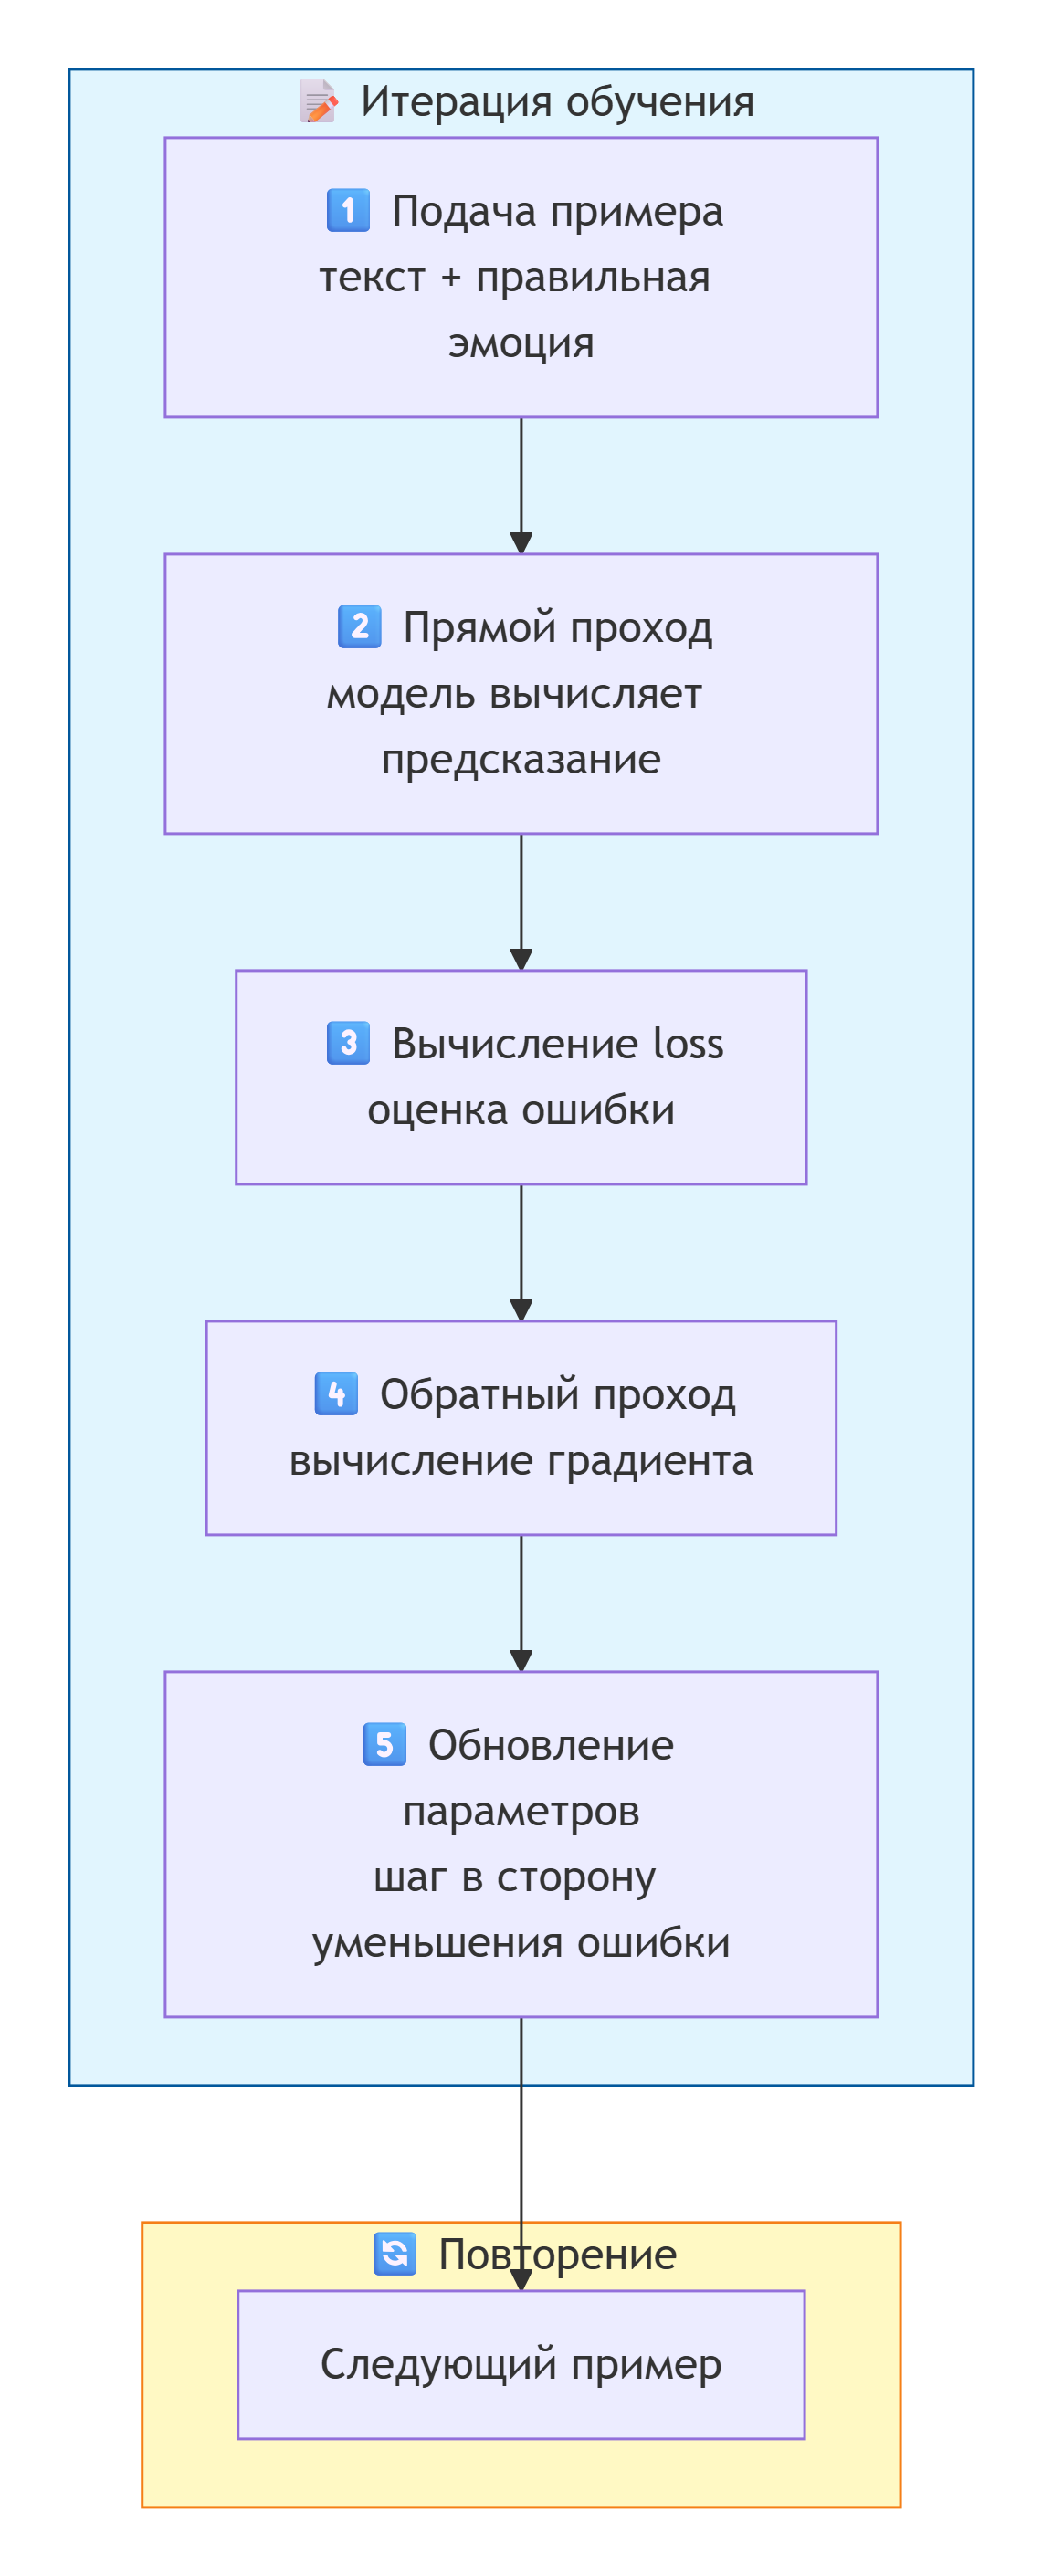


**Пошаговое пояснение:**

1. **Подача примера:** Модель получает текст и правильную эмоцию. Это как если бы мы дали стажёру клинический случай и правильный диагноз.

2. **Прямой проход:** Модель пропускает текст через все свои слои и выдаёт вероятности для каждого класса. Стажёр предлагает свою интерпретацию.

3. **Вычисление loss:** Сравниваем предсказание с правильным ответом. Чем больше разница, тем больше loss. Супервизор оценивает, насколько стажёр ошибся.

4. **Обратный проход:** Модель вычисляет градиент — направление, в котором нужно изменить параметры, чтобы уменьшить ошибку. Стажёр понимает, в каком направлении ему нужно корректировать свой подход.

5. **Обновление параметров:** Модель делает шаг в сторону уменьшения ошибки. Стажёр меняет свой подход на основе обратной связи.

6. **Повторение:** Берём следующий пример и повторяем всё сначала.

**Этот процесс повторяется тысячи раз, пока ошибка не перестанет уменьшаться.**

---

### 2.6. Основные выводы раздела

1. Обучение модели — это процесс настройки миллионов параметров с целью минимизации ошибки на обучающих данных.

2. Функция потерь (loss) количественно оценивает расхождение между предсказанием модели и правильным ответом. Снижение loss в процессе обучения является индикатором того, что модель учится.

3. Градиентный спуск — это алгоритм, который вычисляет направление уменьшения ошибки и обновляет параметры в этом направлении.

4. Скорость обучения (learning rate) контролирует размер шага при обновлении параметров и является критическим гиперпараметром.

5. Понимание этих механизмов позволяет клиницисту критически оценивать качество и ограничения ИИ-систем [5], [7].

---

## 3. ПАРАМЕТРЫ VS ГИПЕРПАРАМЕТРЫ

### 3.1. Параметры (Parameters): что модель учит сама

**Определение:** параметры модели — это внутренние переменные, значения которых **определяются в процессе обучения** на основе данных. Модель «учит» их сама, адаптируясь к закономерностям в обучающей выборке [1], [2].

**Техническое уточнение:** в нейросетях параметрами являются веса связей (weights) и смещения (biases). В модели ruBERT, используемой в Практике 6, их **178 миллионов**.

**Интуитивная аналогия:**

> Представьте, что терапевт учится на супервизии. Он **меняет свой подход** к каждому пациенту на основе опыта: запоминает, какие симптомы с чем связаны, учится замечать паттерны, корректирует свои интерпретации. Это его «параметры» — они меняются в процессе обучения.

**Связь с Практикой 6:** когда мы запускали `trainer.train()`, именно эти 178 миллионов чисел **подстраивались** под нашу задачу классификации эмоций.

---

### 3.2. Гиперпараметры (Hyperparameters): что задаём мы

**Определение:** гиперпараметры — это настройки процесса обучения, которые **задаются исследователем до начала обучения** и не изменяются в процессе [3], [4]. Они определяют, **как** модель будет учиться.

**Интуитивная аналогия:**

> Представьте, что терапевт идёт на супервизию. Гиперпараметры — это **условия супервизии**:
> - Сколько раз в неделю встречаться (число эпох).
> - Как быстро терапевт должен усваивать новый опыт (скорость обучения).
> - Сколько случаев разбирать за одну встречу (размер батча).
>
> Терапевт не выбирает эти условия — их выбирает супервизор (мы). Но они сильно влияют на результат.

**Главные гиперпараметры и их влияние:**

| Гиперпараметр | Что это | Аналогия для психолога | Эффект при изменении |
|---------------|---------|------------------------|---------------------|
| **Learning Rate** | Скорость обучения. Насколько сильно меняются параметры на каждом шаге | Как быстро терапевт меняет подход после обратной связи | Слишком большой — «перепрыгивает» оптимум. Слишком маленький — учится очень медленно |
| **Number of Epochs** | Число эпох. Сколько раз модель видит все данные | Сколько раз терапевт пересматривает случаи | Слишком мало — недообучение. Слишком много — переобучение |
| **Batch Size** | Сколько примеров за один шаг | Сколько пациентов в группе | Маленький — быстрее, но «шумнее». Большой — стабильнее, но медленнее |
| **Weight Decay** | Регуляризация. Штраф за сложность модели | Ограничение: терапевт не должен усложнять интерпретацию без нужды | Большой — модель проще, меньше переобучается |

---

### 3.3. Схема: параметры vs гиперпараметры




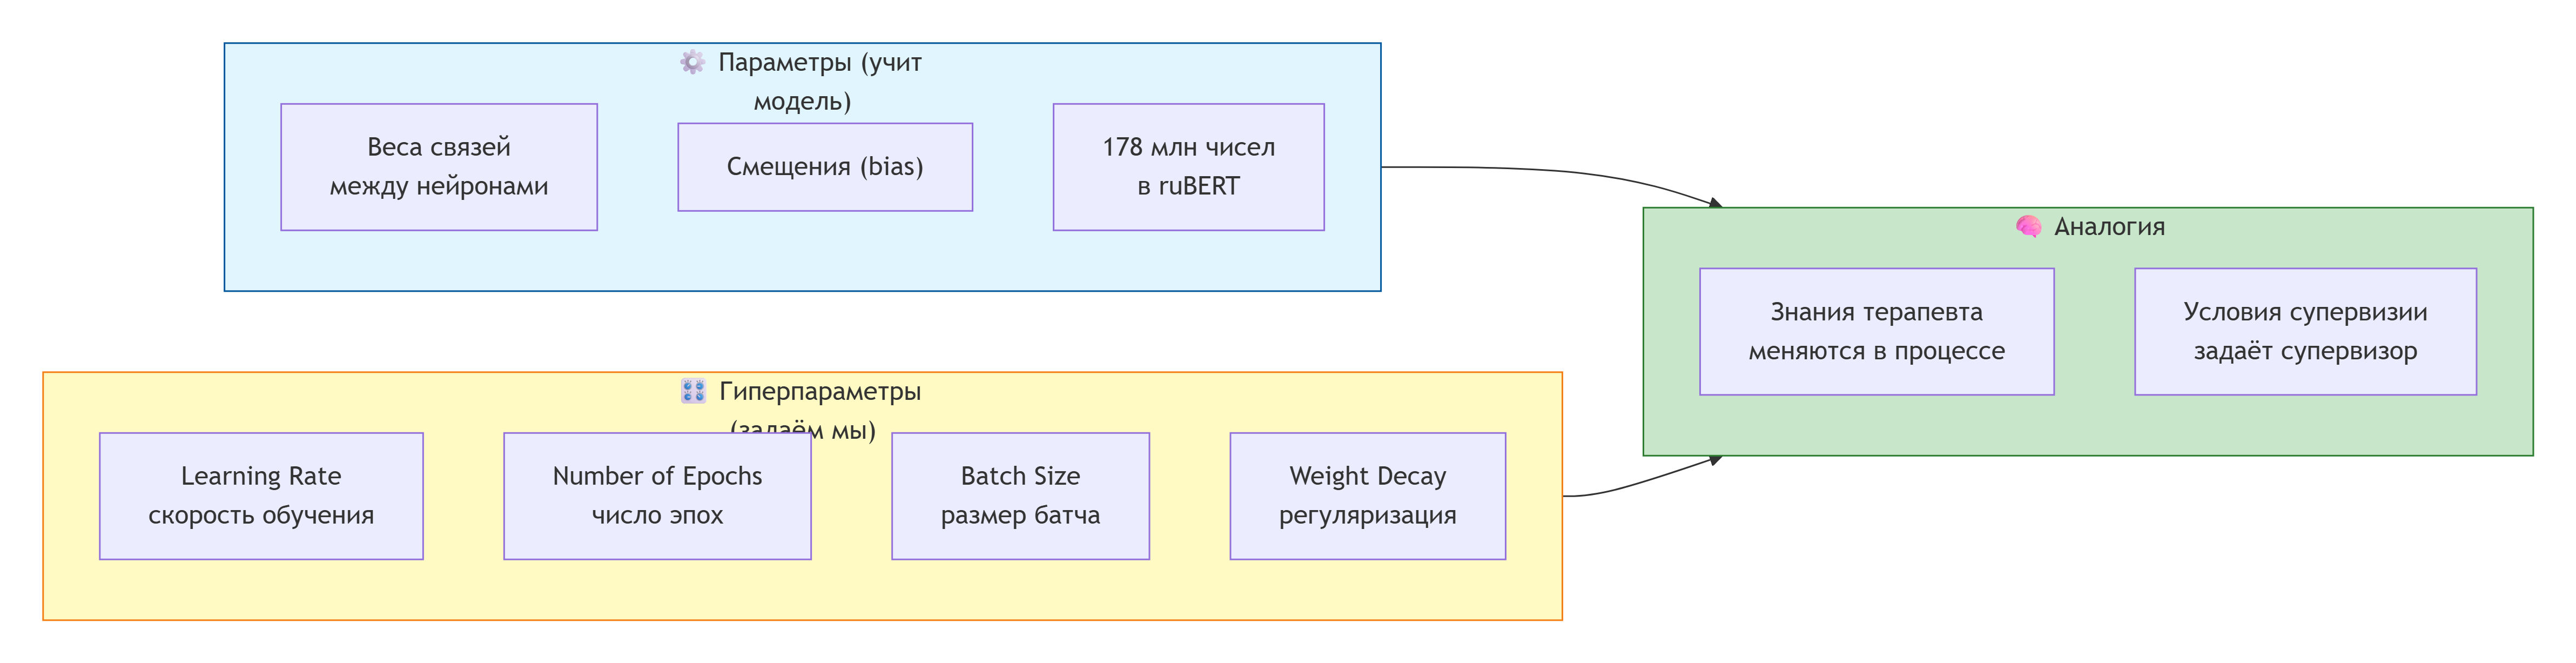


---

### 3.4. Почему это важно для психолога

- **Параметры** — это то, что модель выучила сама. Мы не можем их контролировать напрямую.
- **Гиперпараметры** — это то, что мы контролируем. От их выбора зависит качество обучения.
- Понимание гиперпараметров позволяет **критически оценивать** исследования: если авторы не указывают гиперпараметры, результаты сложно воспроизвести [7].

**Связь с Практикой 6:** мы проводили эксперименты, меняя `learning_rate` и `num_train_epochs`, и наблюдали, как это влияет на accuracy.

---




## 4. РАЗДЕЛЕНИЕ ВЫБОРОК: TRAIN, VALIDATION, TEST

### 4.1. Зачем вообще делить данные?

Представьте, что студент-психолог учится диагностировать депрессию. Вы даёте ему 100 клинических случаев для изучения. Он их выучивает наизусть. Затем вы даёте ему те же 100 случаев на экзамене — он отвечает идеально. Но когда он приходит к реальному пациенту — он не может поставить диагноз.

**Почему?** Он выучил **конкретные случаи**, но не научился **обобщать** (видеть общие закономерности). Он просто запомнил ответы, но не понял принципов.

В машинном обучении это называется **переобучением (overfitting)** — модель запоминает обучающие примеры, но не может работать на новых данных. Чтобы его избежать, мы делим данные на три части.

---

### 4.2. Три типа выборок

| Выборка | Назначение | Аналогия в психологии | Как используется |
|---------|------------|----------------------|------------------|
| **Train** (обучающая) | Модель учится на этих данных. Только на них модель видит правильные ответы | Учебные кейсы, которые студент разбирает с супервизором | Модель «смотрит» на эти данные, учится на них, подстраивает параметры |
| **Validation** (валидационная) | Используется для настройки гиперпараметров и ранней остановки. Модель **не учится** на них, но мы смотрим на ошибку | Контрольные работы, по которым мы понимаем, как студент усваивает материал | Модель **не** учится на этих данных, но мы смотрим на loss и accuracy, чтобы понять, не переобучается ли она |
| **Test** (тестовая) | Используется **один раз в конце** для финальной оценки. Модель никогда не видела эти данные | Финальный экзамен по новым случаям, которые студент не видел раньше | Модель **никогда** не видела эти данные. Мы оцениваем её **один раз** в конце, чтобы понять, как она работает в реальности |

**Ключевое правило:** модель **никогда не должна видеть тестовые данные** до финальной оценки. Иначе мы не можем доверять результатам — модель могла «подглядеть» ответы.

**Связь с Практикой 6:** мы загружали датасет, где данные уже были разделены:
- `train` — 10 000 примеров (обучение).
- `validation` — 2000 примеров (настройка гиперпараметров, ранняя остановка).
- `test` — 2000 примеров (финальная проверка).

---

### 4.3. Как избежать утечки данных (Data Leakage)

**Утечка данных** — это ситуация, когда информация из тестовой или валидационной выборки «просачивается» в процесс обучения. Это одна из самых опасных ошибок в ML, потому что она делает оценку модели нечестной.

**Примеры утечки в психологических исследованиях:**

1. **Предобработка до разделения:**
   - ❌ **Ошибка:** вы нормализуете все данные (train + test) вместе, а потом разделяете.
   - ✅ **Правильно:** сначала разделить, потом нормализовать train, а параметры нормализации (среднее, стандартное отклонение) применить к test.

2. **Использование test для настройки:**
   - ❌ **Ошибка:** вы смотрите на test, видите низкую точность, меняете гиперпараметры и снова запускаете обучение. Тестовая выборка перестаёт быть «независимой».
   - ✅ **Правильно:** test используется **только один раз в конце**. Все настройки — через validation.

3. **Временные данные:**
   - ❌ **Ошибка:** вы используете данные пациентов за 2020–2024 годы. Вы перемешиваете их и случайно делите. В тест попадают пациенты из 2020 года, а модель обучается на данных из 2024 года — она «знает будущее».
   - ✅ **Правильно:** делить по времени (например, train = 2020–2022, validation = 2023, test = 2024).

**Интуитивная аналогия:**

> Представьте, что вы готовите студента к экзамену. Утечка данных — это когда вы даёте ему **те же самые вопросы**, которые будут на экзамене. Он выучит их наизусть, но не поймёт предмет. На реальных пациентах он провалится.

**Связь с Практикой 6:** мы использовали уже готовое разделение в датасете, поэтому утечки данных не было. Но если бы мы создавали свой датасет, нужно было бы помнить об этих правилах.

---

### 4.4. Схема: правильное разделение данных

```mermaid
flowchart LR
    subgraph Данные[📊 Все данные]
        D[Исходный датасет]
    end
    
    subgraph Разделение[✂️ Разделение]
        T[🚂 Train<br>70%]
        V[🛤️ Validation<br>15%]
        Te[🧪 Test<br>15%]
    end
    
    subgraph Процесс[⚙️ Процесс]
        P1[Модель учится]
        P2[Настройка<br>гиперпараметров]
        P3[Финальная<br>оценка]
    end
    
    Данные --> Разделение
    T --> P1
    V --> P2
    Te --> P3
    
    style T fill:#c8e6c9,stroke:#2e7d32
    style V fill:#fff9c4,stroke:#f57f17
    style Te fill:#ffcdd2,stroke:#c62828
```

**Пояснение:**
- **Train (70%)** — модель учится на этих данных.
- **Validation (15%)** — используем для настройки гиперпараметров. Модель не учится, но мы видим её ошибку.
- **Test (15%)** — используется **один раз в конце** для финальной оценки.

---



## 5. ГРАФИКИ ОБУЧЕНИЯ: КАК ЧИТАТЬ КРИВЫЕ LOSS И ACCURACY

### 5.1. Что показывают графики обучения

В Практике 6 мы строили два основных графика:
1. **Loss (ошибка)** — чем ниже, тем лучше. Показывает, насколько модель ошибается.
2. **Accuracy (точность)** — чем выше, тем лучше. Показывает долю правильных ответов.

Но важно смотреть **не только на финальные значения**, но и на **динамику** и **соотношение** train и validation кривых. Именно в этом соотношении скрываются признаки переобучения или недообучения.

---

### 5.2. Идеальное обучение

```mermaid
flowchart LR
    subgraph Идеал[✅ Идеальное обучение]
        L1[📉 Train Loss<br>плавно снижается]
        L2[📉 Val Loss<br>тоже снижается]
        A1[📈 Train Acc<br>плавно растёт]
        A2[📈 Val Acc<br>тоже растёт]
    end
    
    subgraph Что_значит[🧠 Что это значит]
        M1[Модель учится<br>и может обобщать]
        M2[Можно продолжать<br>обучение]
    end
    
    Идеал --> Что_значит
    
    style Идеал fill:#c8e6c9,stroke:#2e7d32
```

**Характеристики:**
- Train loss снижается, val loss тоже снижается.
- Train accuracy растёт, val accuracy тоже растёт.
- Кривые идут близко друг к другу (нет большого разрыва).

**Что это значит:** модель успешно учится и может применять знания на новых данных. Можно продолжать обучение (пока loss не перестанет снижаться).

**Связь с Практикой 6:** в нашем эксперименте с базовыми параметрами мы видели именно такую картину — обе кривые шли в правильном направлении.

---

### 5.3. Переобучение (Overfitting)

```mermaid
flowchart LR
    subgraph Переобучение[⚠️ Переобучение]
        L1[📉 Train Loss<br>очень низкий]
        L2[📈 Val Loss<br>растёт]
        A1[📈 Train Acc<br>очень высокий]
        A2[📉 Val Acc<br>падает]
    end
    
    subgraph Что_значит[🧠 Что это значит]
        M1[Модель запомнила<br>примеры, но не понимает<br>общие закономерности]
        M2[Пора остановить<br>обучение]
    end
    
    Переобучение --> Что_значит
    
    style Переобучение fill:#ffcdd2,stroke:#c62828
```

**Характеристики:**
- Train loss очень низкий (модель почти не ошибается на обучении).
- Val loss **начинает расти**! Это главный признак переобучения.
- Train accuracy очень высокий (90+%).
- Val accuracy **падает**.
- Большой разрыв между train и val кривыми.

**Что это значит:** модель **запомнила** обучающие примеры, но не научилась **обобщать**. На новых данных она будет работать плохо.

**Аналогия для психолога:**

> Терапевт выучил всех своих пациентов наизусть. Он знает, что сказать каждому из них. Но когда приходит новый пациент — он теряется. Он не понимает общих закономерностей, он просто «запомнил» конкретные случаи.

**Что делать в Практике 6:**
- Уменьшить число эпох (ранняя остановка).
- Уменьшить learning rate.
- Добавить регуляризацию (weight decay).
- Увеличить объём данных (если возможно).

---

### 5.4. Недообучение (Underfitting)

```mermaid
flowchart LR
    subgraph Недообучение[⚠️ Недообучение]
        L1[📉 Train Loss<br>высокий]
        L2[📉 Val Loss<br>тоже высокий]
        A1[📈 Train Acc<br>низкий]
        A2[📉 Val Acc<br>тоже низкий]
    end
    
    subgraph Что_значит[🧠 Что это значит]
        M1[Модель слишком простая<br>или училась слишком мало]
        M2[Нужно продолжить<br>обучение]
    end
    
    Недообучение --> Что_значит
    
    style Недообучение fill:#fff9c4,stroke:#f57f17
```

**Характеристики:**
- Train loss высокий, val loss тоже высокий.
- Train accuracy низкий, val accuracy тоже низкий.
- Кривые идут близко, но на низком уровне.

**Что это значит:** модель **недоучилась**. Она слишком простая или училась слишком мало.

**Аналогия для психолога:**

> Терапевт прошёл только одну супервизию и уже считает себя готовым. Он не знает ни теорий, ни методов. Его интерпретации поверхностны и неточны. Ему нужно больше учиться.

**Что делать в Практике 6:**
- Увеличить число эпох.
- Увеличить learning rate.
- Взять более сложную модель (с большим числом параметров).
- Проверить качество данных.

---

### 5.5. Таблица: как распознать состояние обучения

| Что видим на графиках | Состояние | Что делать |
|-----------------------|-----------|------------|
| Train loss ↓, Val loss ↓, разрыв мал | ✅ Идеальное обучение | Продолжать, остановиться, когда val loss перестаёт снижаться |
| Train loss ↓, Val loss ↑, разрыв растёт | ⚠️ Переобучение | Уменьшить эпохи, уменьшить LR, добавить регуляризацию |
| Train loss высокий, Val loss высокий | ⚠️ Недообучение | Увеличить эпохи, увеличить LR, усложнить модель |
| Train loss ↓, Val loss застыл | Модель перестала учиться | Увеличить LR, проверить данные |





## 6. МЕТРИКИ ДЛЯ КЛАССИФИКАЦИИ

### 6.1. Почему accuracy не всегда лучшая метрика

**Accuracy (точность)** — это доля правильно предсказанных примеров.

**Проблема:** accuracy может быть высокой, даже если модель работает плохо, — если классы несбалансированы.

**Пример из психологии:**

> Представьте, что мы создаём модель для выявления депрессии. В популяции депрессия встречается у 5% людей. Если модель всегда предсказывает «нет депрессии», её accuracy будет 95%! Но она не выявит ни одного пациента с депрессией. Это катастрофа.

**Поэтому нужны другие метрики.**

---

### 6.2. Матрица ошибок (Confusion Matrix)

Чтобы понять остальные метрики, нужно сначала понять матрицу ошибок — таблицу, которая показывает, где модель ошибается.

| | Предсказано: Депрессия | Предсказано: Нет депрессии |
|---|---|---|
| **На самом деле: Депрессия** | **True Positive (TP)**<br>Правильно выявили депрессию | **False Negative (FN)**<br>Пропустили депрессию (опасно!) |
| **На самом деле: Нет депрессии** | **False Positive (FP)**<br>Ложная тревога | **True Negative (TN)**<br>Правильно определили здорового |

**Интуитивная аналогия:**

> - **TP** — терапевт правильно поставил диагноз «депрессия».
> - **TN** — терапевт правильно сказал, что депрессии нет.
> - **FP** — терапевт сказал «депрессия», а её нет (ложная тревога).
> - **FN** — терапевт сказал «нет депрессии», а она есть (пропустил опасное состояние).

---

### 6.3. Precision, Recall, F1 — и зачем они нужны

**Precision (точность предсказания класса):**

> Из всех случаев, где модель сказала «депрессия», сколько действительно были депрессией?

`Precision = TP / (TP + FP)`

**Интуиция:** насколько модели можно доверять, когда она говорит «депрессия». Если precision низкая, модель часто ошибается (ложные тревоги).

**Recall (полнота, чувствительность):**

> Из всех реальных случаев депрессии, сколько модель правильно выявила?

`Recall = TP / (TP + FN)`

**Интуиция:** насколько хорошо модель находит депрессию, не пропуская пациентов. Если recall низкая, модель пропускает больных (опасно!).

**F1-score:**

> Среднее гармоническое precision и recall.

`F1 = 2 × (Precision × Recall) / (Precision + Recall)`

**Интуиция:** баланс между precision и recall. Используется, когда важны обе метрики.

---

### 6.4. Какую метрику выбрать в психологии?

| Задача | Важнее | Почему |
|--------|--------|--------|
| **Скрининг депрессии** | **Recall** | Важно не пропустить ни одного пациента. Лучше ложная тревога (FP), чем пропущенная депрессия (FN) |
| **Диагностика редкого расстройства** | **Recall** | Ещё важнее — не пропустить редкое, но опасное состояние |
| **Оценка риска суицида** | **Recall** | **Критически важно:** нельзя пропустить суицидальный риск. FP лучше, чем FN |
| **Подбор терапии** | **Precision** | Если модель говорит, что пациенту подойдёт КПТ, важно, чтобы это было правдой (иначе зря потратим время) |
| **Исследовательские цели** | **F1** | Нужен баланс между точностью и полнотой |

**Связь с Практикой 6:** мы считали все четыре метрики (`accuracy`, `precision`, `recall`, `f1`) и смотрели на них. Для задачи классификации эмоций accuracy была основной метрикой, но для клинических задач выбор метрики был бы другим.

---

### 6.5. Схема: выбор метрики в психологии

```mermaid
flowchart TD
    Start[🎯 Какая задача?]
    
    Start --> Q1[Важнее не пропустить<br>опасное состояние?]
    Q1 -->|Да| Recall[🎯 Выбираем RECALL<br>скрининг депрессии<br>выявление суицидального риска]
    Q1 -->|Нет| Q2[Важнее не ошибаться,<br>когда модель даёт прогноз?]
    Q2 -->|Да| Precision[🎯 Выбираем PRECISION<br>подбор терапии<br>рекомендации лекарств]
    Q2 -->|Нет| F1[🎯 Выбираем F1<br>исследовательские задачи<br>когда нужен баланс]
    
    style Recall fill:#ffcdd2,stroke:#c62828
    style Precision fill:#e1f5fe,stroke:#01579b
    style F1 fill:#c8e6c9,stroke:#2e7d32
```





## 7. СВЯЗЬ С ДООБУЧЕНИЕМ (FINE-TUNING)

### 7.1. Что такое дообучение (fine-tuning)?

**Определение:** дообучение — это процесс, когда мы берём **предобученную модель** (которая уже знает язык) и **донастраиваем** её на **конкретной задаче** (например, классификация эмоций).

**Интуитивная аналогия:**

> Представьте, что модель — это терапевт, который закончил университет (предобучение). Он знает общую психологию, теории, методы. Но он не знает, как работать с конкретным расстройством. Дообучение — это **супервизия** по конкретному направлению (например, работа с ПТСР). Терапевт берёт свои общие знания и адаптирует их под специфику.

---

### 7.2. Что происходит при дообучении

1. Мы берём предобученную модель (например, ruBERT) — 178 миллионов параметров уже настроены на понимание русского языка.
2. Мы **заменяем последний слой** модели на новый, который соответствует нашей задаче (4 класса эмоций вместо тысяч классов из предобучения).
3. Мы **обучаем** модель на нашем датасете — но с **маленькой скоростью обучения** (learning rate = 2e-5), чтобы не «сломать» знания, которые модель уже получила.
4. Мы следим за графиками, чтобы не переобучить модель.

**Связь с Практикой 6:**
- Мы брали `AutoModelForSequenceClassification.from_pretrained()` — это предобученная модель.
- Мы меняли последний слой (`num_labels=4`).
- Мы обучали с маленьким learning rate (`2e-5`).
- Мы следили за графиками, чтобы остановиться вовремя.

---

### 7.3. Почему важно понимать процесс обучения

- Дообучение — это **эффективный способ** адаптировать мощные модели под конкретные задачи.
- Без понимания процесса обучения вы не сможете правильно настроить гиперпараметры и интерпретировать результаты.
- В клинической практике это помогает вам **критически оценивать** ИИ-системы: понимать, почему они могут ошибаться, и доверять ли им.

**Этический вывод:** модель — это инструмент. Она может ошибаться. В психиатрии ошибочный прогноз может иметь серьёзные последствия. Доверяйте, но проверяйте. Понимание того, как модель учится, — это первый шаг к ответственному использованию ИИ в клинике.

---



## 8. ЗАКЛЮЧЕНИЕ

**Что мы сегодня узнали:**

| Что узнали | Ключевая идея | Аналогия для психолога |
|------------|---------------|----------------------|
| **Что такое обучение** | Настройка параметров модели для уменьшения ошибки | Терапевт учится на супервизии |
| **Функция потерь** | Измеряет, насколько модель ошиблась | Оценка ошибки студента |
| **Градиентный спуск** | Алгоритм, который показывает, куда двигаться | Спуск с горы в тумане |
| **Параметры vs гиперпараметры** | Параметры учит модель, гиперпараметры задаём мы | Веса терапевта (параметры) vs условия супервизии (гиперпараметры) |
| **Разделение данных** | Train, validation, test — три разные выборки | Учебные кейсы, контрольные, экзамен |
| **Графики обучения** | Как читать loss и accuracy, распознавать переобучение | Как понять, что терапевт запоминает случаи, а не учится |
| **Метрики** | Accuracy, precision, recall, F1 — разные взгляды на качество | В психологии recall важнее accuracy (не пропустить депрессию) |

**Ключевая мысль на сегодня:**

> Понимание процесса обучения — это не «техническая деталь». Это **ключ к критической оценке** любой ИИ-системы. Если вы понимаете, как модель учится, вы понимаете, когда ей можно доверять, а когда — нет. В психологии, где цена ошибки высока, это знание становится **этической необходимостью**.

**Связь с будущим:**
- В следующих лекциях мы будем говорить о **конкретных применениях** ИИ в психологии — диагностика, персонализация терапии, прогнозирование исходов.
- Понимание процесса обучения поможет вам **задавать правильные вопросы** к этим системам: *«На каких данных она обучена? Как она делила выборку? Не переобучилась ли она? Какую метрику она оптимизировала?»*

---

## 9. ВОПРОСЫ ДЛЯ САМОПРОВЕРКИ (10 шт.)

1. Что такое функция потерь (loss function)? Приведите аналогию из психотерапии.

2. Что такое градиентный спуск? Объясните на примере спуска с горы.

3. В чём разница между параметрами и гиперпараметрами модели? Приведите примеры тех и других.

4. Зачем делить данные на train, validation и test? Что произойдёт, если использовать test для настройки гиперпараметров?

5. Что такое утечка данных (data leakage)? Приведите пример в контексте психологического исследования.

6. Как выглядит график обучения при переобучении (overfitting)? Что нужно сделать, чтобы исправить ситуацию?

7. Как выглядит график обучения при недообучении (underfitting)? Что нужно сделать, чтобы исправить ситуацию?

8. Что такое precision и recall? Какая метрика важнее для скрининга депрессии и почему?

9. Что такое F1-score и когда его используют?

10. **Этический вопрос:** представьте, что модель для выявления суицидального риска показывает precision = 90% и recall = 60%. Можно ли её использовать в клинике? Почему да или почему нет?

---

## 10. ДОМАШНЕЕ ЗАДАНИЕ (срок — 2 недели)

**Часть 1. Анализ графиков обучения (2–3 страницы)**

Вам даны три набора графиков обучения (воображаемых). Для каждого набора определите состояние обучения и предложите действия.

**Набор А:**
- Train loss: 2.5 → 1.2 → 0.8 → 0.7 → 0.65
- Val loss: 2.6 → 1.5 → 1.1 → 1.2 → 1.4
- Train acc: 0.40 → 0.60 → 0.75 → 0.80 → 0.82
- Val acc: 0.38 → 0.55 → 0.65 → 0.63 → 0.60

**Набор Б:**
- Train loss: 2.5 → 2.4 → 2.3 → 2.3 → 2.2
- Val loss: 2.6 → 2.5 → 2.4 → 2.4 → 2.3
- Train acc: 0.40 → 0.42 → 0.43 → 0.44 → 0.44
- Val acc: 0.38 → 0.39 → 0.40 → 0.40 → 0.41

**Набор В:**
- Train loss: 2.5 → 1.0 → 0.5 → 0.3 → 0.2
- Val loss: 2.6 → 1.5 → 1.0 → 0.9 → 0.85
- Train acc: 0.40 → 0.70 → 0.85 → 0.92 → 0.95
- Val acc: 0.38 → 0.60 → 0.72 → 0.74 → 0.73

---

**Часть 2. Выбор метрики для психологической задачи (2 страницы)**

Даны три клинические задачи. Для каждой определите главную метрику и объясните почему.

**Задача А.** Модель для скрининга депрессии в общей популяции (депрессия у 5% людей).

**Задача Б.** Модель для подбора терапии: определяет, подойдёт ли пациенту КПТ или медикаментозное лечение.

**Задача В.** Модель для выявления суицидального риска по текстам постов в социальных сетях.

---

**Часть 3. Рефлексия о переобучении в психологии (1–2 страницы)**

Напишите эссе на тему: *«Может ли терапевт "переобучиться"? И что мы можем сделать, чтобы этого избежать?»*

Включите:
- Аналогию между переобучением модели и «запоминанием случаев» в психотерапии.
- Какие практики в психотерапии помогают терапевту «обобщать», а не «запоминать»?
- Как супервизия, интервизия, работа с разными пациентами и постоянное обучение помогают избежать «клинического переобучения»?

---

**Часть 4. Дополнительное задание (для желающих) — этический анализ**

Представьте, что вы — клинический психолог. К вам приходит компания-разработчик с предложением внедрить модель для диагностики депрессии по тексту. Модель показывает:
- Accuracy: 92%
- Precision: 88%
- Recall: 70%

Напишите краткий отчёт (1 страница):
- Согласитесь ли вы использовать эту модель в своей практике?
- Какие вопросы вы зададите разработчикам перед внедрением?
- Какие меры предосторожности вы предложите?

---

## 11. ЛИТЕРАТУРА

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
2. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.
3. Géron, A. (2023). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly.
4. Scikit-learn Documentation (2024). *Model evaluation: metrics*. https://scikit-learn.org/stable/modules/model_evaluation.html
5. Крылов, В. (2025). *Метрики классификации в клинической психологии: выбор и интерпретация*. Журнал медицинской психологии, 14(2), 45–53.
6. Hugging Face Documentation (2024). *Fine-tuning with Trainer*. https://huggingface.co/docs/transformers/en/training
7. Севостьянов, А. (2024). *Интерпретация графиков обучения нейросетей: руководство для психологов*. Когнитивные науки и психология, 9(1), 78–89.


## 4. ЛИТЕРАТУРА (ДЛЯ ПЕРВОЙ ЧАСТИ)

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.
2. Chollet, F. (2021). *Deep Learning with Python* (2nd ed.). Manning Publications.
3. Géron, A. (2023). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3rd ed.). O'Reilly.
4. Scikit-learn Documentation (2024). *Model evaluation: metrics*. https://scikit-learn.org/stable/modules/model_evaluation.html
5. Крылов, В. (2025). *Метрики классификации в клинической психологии: выбор и интерпретация*. Журнал медицинской психологии, 14(2), 45–53.
6. Hugging Face Documentation (2024). *Fine-tuning with Trainer*. https://huggingface.co/docs/transformers/en/training
7. Севостьянов, А. (2024). *Интерпретация графиков обучения нейросетей: руководство для психологов*. Когнитивные науки и психология, 9(1), 78–89.